# What are the most demanded skills for the top 3 most popular data roles?
### Method
    1. Clean-up job_skills column.
    2. Calculate skill count based on job_title_short.
    3. Calculate skill percentage.
    4. Plot final findings.

## Import Libraries and Data

In [ ]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## Filter Data for the US
Filter the data for the market of the US

In [3]:
df_US = df[df['job_location'] == 'United States']

## Explode Skills

Converts the job_skills column from string representations of lists into actual list objects and then expands these lists so each skill appears in its own row. It then displays the job_title and job_skills columns, allowing us to analyse the distribution of skills across different data job titles.

In [29]:
df_skills = df_US.explode('job_skills')
df_skills = df_skills.dropna(subset=['job_skills'])

df_skills[['job_skills', 'job_title']]

,job_skills,job_title
156,sql,Data Engineer
156,excel,Data Engineer
372,python,Data Scientist/Analyst
572,python,Data Scientist I
572,r,Data Scientist I
...,...,...
785557,python,"Data Scientist, All Levels"
785557,c,"Data Scientist, All Levels"
785557,shell,"Data Scientist, All Levels"
785557,bash,"Data Scientist, All Levels"


## Count Skills per Job Title

Groups DataFrame by job_skills and job_title_short, counting the occurrences of each skill within each job title. Then resets the index of the Series to turn it back into a DataFrame and renames the series holding the count to 'count'. The final DataFrame, df_skills_count, shows the frequency of each skill with each job title.

In [30]:
# Group by job_title and job_skillsand count the number occurences
df_skills_count = df_skills.groupby(['job_title_short', 'job_skills']).size()

# Name the count column as count
df_skills_count = df_skills_count.reset_index(name='skill_count')

# Sort the values by skill_count in descending order
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

,job_title_short,job_skills,skill_count
455,Data Scientist,python,3113
484,Data Scientist,sql,2164
458,Data Scientist,r,1882
494,Data Scientist,tableau,940
468,Data Scientist,sas,936
...,...,...,...
960,Software Engineer,node,1
31,Business Analyst,word,1
2,Business Analyst,azure,1
0,Business Analyst,airflow,1


## Create List of Top 3 Roles
#### Focus: Data Analysts, Data Engineers and Data Scientists
Filter the job titles based on the most popular.

In [31]:
job_titles = df_skills_count['job_title_short'].unique().tolist()

job_titles = sorted(job_titles[:3])

job_titles

['Data Engineer', 'Data Scientist', 'Senior Data Scientist']

## Plot Skill Counts
Creates a stacked horizontal bar chart for the top 5 skills for top 3 roles, displaying the frequency of each skill.

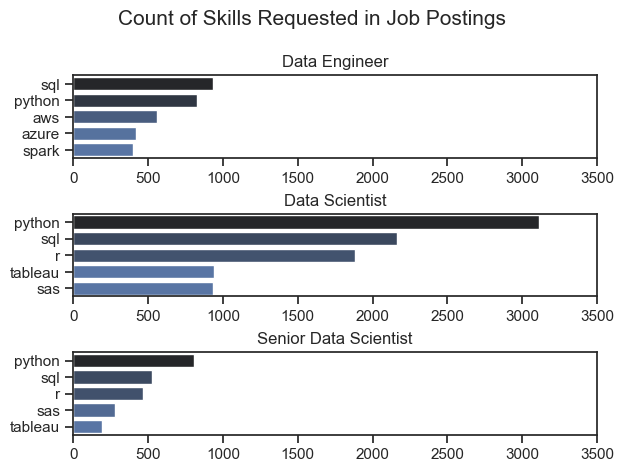

In [32]:
fig, ax = plt.subplots(len(job_titles), 1)

sns.set_theme(style="ticks")

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)[::-1]
    sns.barplot(data=df_plot, x='skill_count', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 3500)

fig.suptitle('Count of Skills Requested in Job Postings', fontsize=15)
fig.tight_layout(h_pad=0.5)
plt.show()

## Converting Counts to Percentage
#### Focus: Counts do not show what portions of jobs are  requesting these skills
So we'll convert the counts into percentages which helps us understand how each job title represents relative to the entire dataset.

Before we can calculate the percentages we need the total counts for the jobs posted by job title. Calculate the frequency of each job title using the value_counts() method on the job_title_short column. Then reset the index to transform the Series into a DataFrame and renames the columns to job_title_short and total. The DataFrame df_job_title_count now holds a list of job titles alongside their total occurrences.

In [33]:
# Use original df to get the count of job titles
df_job_title_count = df_US['job_title_short'].value_counts().reset_index(name='jobs_total')

df_job_title_count

,job_title_short,jobs_total
0,Data Scientist,4319
1,Data Engineer,1334
2,Senior Data Scientist,1034
3,Senior Data Engineer,334
4,Data Analyst,224
5,Machine Learning Engineer,82
6,Software Engineer,53
7,Senior Data Analyst,51
8,Business Analyst,14
9,Cloud Engineer,9


Then we calculate the percentages. First merge df_skills_count and df_job_title_count, based on the 'job_title_short' column, ensuring each skill count is associated with the total number of job postings for that title. Then calculate the percentage of each skill within its job title by dividing the skill count by the total job postings and multiplying by 100, adding this new data as a 'percentage' column.

In [34]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, on='job_title_short', how='left')

df_skills_perc['skill_percent'] = (df_skills_perc['skill_count'] / df_skills_perc['jobs_total']) * 100

df_skills_perc

,job_title_short,job_skills,skill_count,jobs_total,skill_percent
0,Data Scientist,python,3113,4319,72.076870
1,Data Scientist,sql,2164,4319,50.104191
2,Data Scientist,r,1882,4319,43.574902
3,Data Scientist,tableau,940,4319,21.764297
4,Data Scientist,sas,936,4319,21.671683
...,...,...,...,...,...
987,Software Engineer,node,1,53,1.886792
988,Business Analyst,word,1,14,7.142857
989,Business Analyst,azure,1,14,7.142857
990,Business Analyst,airflow,1,14,7.142857


## Plot Percentage Count
Filters and sorts a DataFrame to get the top 5 skills percentages for these top 3 roles. After sorting the skills by descending percentage, reverse the order of these top 5 entries to use in a horizontal bar plot, which by default starts plotting from the bottom.

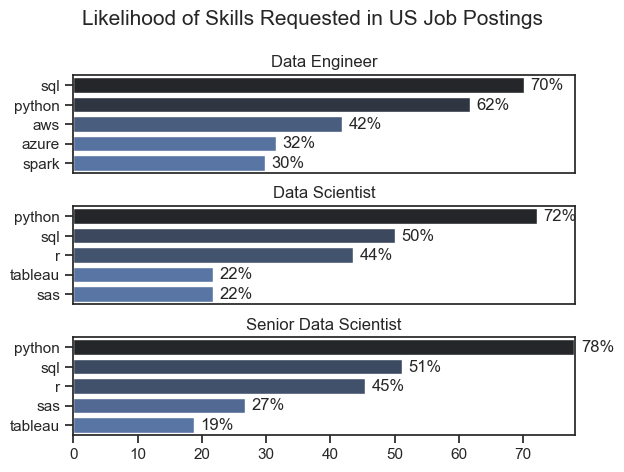

In [35]:
fig, ax = plt.subplots(len(job_titles), 1)


for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_percent', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r')
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].get_legend().remove()
    ax[i].set_xlim(0, 78)
    
    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

    
    for n, v in enumerate(df_plot['skill_percent']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=15)
fig.tight_layout(h_pad=.8)
plt.show()